# Model Analysis

This notebook does the following:

1. Loads VISUAL data from 4 mice. This data is composed of neural data + DINO features of videos.
2. Loads the trained models (cf. ModelGeneratorVISUAL.inpyb)
3. Compares embeddings.
4. Does a Neural Network Analysis composed of the following:
  - vizualization across layers of:
    - Single-Unit activation
    - CEBRA embedding across layers
    - t-SNE embeddings across layers
    - CKA
    - RDM



In [2]:
cd ..

/Users/riccardocarpineto/Documents/CEBRA/t/Sans titre


In [3]:
import sys
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import sklearn.metrics
import statsmodels.api as sm
import cebra.data
import cebra.datasets
import cebra.integrations
from cebra import CEBRA
from tqdm import tqdm
from scipy.linalg import block_diag
from scipy.spatial.distance import cosine, correlation
from src.preprocessing.CEBRA_preprocessing.utils_allen import *
import importlib
import src.preprocessing.CEBRA_preprocessing.utils as utils
# Reload the utils module
importlib.reload(utils)
from src.preprocessing.CEBRA_preprocessing.utils import plot_hippocampus,plot_allen # make sure you are in the root directory, use pwd to check

# TO PUT IN UTILS

In [4]:
def split_data_HPC(data, test_ratio):

    split_idx = int(len(data)* (1-test_ratio))
    neural_train = data.neural[:split_idx]
    neural_test = data.neural[split_idx:]
    label_train = data.continuous_index[:split_idx]
    label_test = data.continuous_index[split_idx:]

    return neural_train.numpy(), neural_test.numpy(), label_train.numpy(), label_test.numpy()
# Define decoding function with kNN decoder. For a simple demo, we will use the fixed number of neighbors 36.
def decoding_pos_dir(embedding_train, embedding_test, label_train, label_test):
   pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
   dir_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")

   pos_decoder.fit(embedding_train, label_train[:,0])
   dir_decoder.fit(embedding_train, label_train[:,1])

   pos_pred = pos_decoder.predict(embedding_test)
   dir_pred = dir_decoder.predict(embedding_test)

   prediction = np.stack([pos_pred, dir_pred],axis = 1)

   test_score = sklearn.metrics.r2_score(label_test[:,:2], prediction)
   pos_test_err = np.median(abs(prediction[:,0] - label_test[:, 0]))
   pos_test_score = sklearn.metrics.r2_score(label_test[:, 0], prediction[:,0])

   return test_score, pos_test_err, pos_test_score

def plot_tsne_embeddings_layers(embeddings_tsne_untrained, embeddings_tsne_trained,labels,sample_plot = 100, solver = 'single-session', comparison = 'untrained',data = 'HPC'):


    num_layers = len(embeddings_tsne_trained)

    fig, axs = plt.subplots(2, num_layers, figsize=(15, 10), subplot_kw={'projection': '3d'})

    # Flatten the array of axes for easier indexing
    axs = axs.flatten()

    # Separate the axes into untrained and trained lists
    axs_untrained = axs[:num_layers]
    axs_trained = axs[num_layers:]


    # Prepare data for embedding, labels, and titles
    '''labels_list = [label_extended[1:-1], label_extended[2:-2], label_extended[4:-4],
                  label_extended[5:-5], label_extended[5:-5]]''' # COMPUTE ALL THE EMBEDINGS AFTER

    labels_list = [labels[:sample_plot]] * num_layers

    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Untrained', f'Layer {layer} Trained'))
      titles.append(('Output untrained','Output Trained'))
    else:
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Trained', f'Layer {layer} Trained'))
      titles.append(('Output Single','Output Multi'))

    i = 0
    for label, ax, ax_trained in zip( labels_list, axs_untrained, axs_trained):
        embedding = embeddings_tsne_untrained[i][:sample_plot,:]
        embedding_trained = embeddings_tsne_trained[i][:sample_plot,:]
        if data == 'HPC':
          ax = plot_hippocampus(ax, embedding, label)
        else:
          ax = plot_allen(ax, embedding, label)

        ax.set_title(titles[i][0], y=1)
        ax.axis('off')
        if data =='HPC':
          ax_trained = plot_hippocampus(ax_trained, embedding_trained, label)
        else:
          ax_trained = plot_allen(ax_trained, embedding_trained, label)

        ax_trained.set_title(titles[i][1], y=1)
        ax_trained.axis('off')
        i = i + 1

    fig.suptitle(f't-SNE across layers ({solver})', fontsize= 20)

    plt.subplots_adjust(wspace=0,
                        hspace=0)
    plt.tight_layout()

    plt.show()


def plot_activations(input_data,embeddings_untrained,embeddings_trained,sample_plot = 100, solver = 'single', comparison = 'untrained'):
    num_layers = len(embeddings_trained)

    # Set up the figure and gridspec layout
    fig = plt.figure(figsize=(10, 15))
    fig.suptitle(f'Comparison between layers ({solver})', fontsize=20)
    gs = gridspec.GridSpec(num_layers+1, 2)  # Create a grid with 5 rows and 2 columns

    # Create a subplot that spans both columns for the top plot
    ax_top = fig.add_subplot(gs[0, :])  # Top row, spanning both columns
    ax_top.imshow(input_data.T[:, 0:sample_plot])
    ax_top.set_title('Input Data')
    #ax_top.axis('off')
    ax_top.set_ylabel('Channel #')
    ax_top.set_xlabel('Time')
    ax_top.grid(False)

    # Now set up the existing subplots for the comparisons
    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append(f'Layer {layer} Untrained')
          titles.append(f'Layer {layer} Trained')
      titles.append(f'Output Untrained')
      titles.append(f'Output Trained')
    else:
      for layer in range(1, num_layers):
          titles.append(f'Layer {layer} Single')
          titles.append(f'Layer {layer} Multi')

      titles.append(f'Output Single')
      titles.append(f'Output Multi')

    # Create each subplot
    axes = []
    for i in range(num_layers):
        for j in range(2):
            ax = fig.add_subplot(gs[i + 1, j])  # Shift down by 1 row for each layer
            axes.append(ax)

    # Interleave untrained and trained embeddings
    ax_images = [None] * (2 * num_layers)
    ax_images[::2] =  embeddings_untrained# Place untrained embeddings at even indices
    ax_images[1::2] =  embeddings_trained # Place trained embeddings at odd indices

    for ax, img, title in zip(axes, ax_images, titles):
        ax.imshow(img[:, 0:sample_plot], cmap = 'magma')
        ax.set_title(title)
        ax.set_ylabel('Unit #')
        ax.set_xlabel('Time')
        ax.grid(False)  # Hide gridlines
        #ax.axis('off')  # Hide axis for the subplots

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


def plot_cebra_embeddings_layers(embeddings_untrained,embeddings_trained,labels_list, solver, comparison = 'untrained',dataset = 'HPC'):

    num_layers = len(embeddings_trained)

    fig, axs = plt.subplots(2, num_layers, figsize=(15, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(f'Embeddings across layers ({solver})', fontsize=20)

    # Flatten the array of axes for easier indexing
    axs = axs.flatten()

    # Separate the axes into untrained and trained lists
    axs_untrained = axs[:num_layers]
    axs_trained = axs[num_layers:]

    # Now set up the existing subplots for the comparisons
    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Untrained', f'Layer {layer} Trained'))
      titles.append(('Output untrained','Output Trained'))
    else:
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Single', f'Layer {layer} Multi'))
      titles.append(('Output Single','Output Multi'))

    i = 0
    for label, ax, ax_trained in zip(labels_list, axs_untrained, axs_trained):
        emb_untrained = embeddings_untrained[i].T
        emb_trained = embeddings_trained[i].T
        if dataset == 'HPC':
           ax = plot_hippocampus(ax, emb_untrained, label)
        else:
          ax = plot_allen(ax, emb_untrained, label)

        ax.set_title(titles[i][0], y=1, pad=-20)
        ax.axis('off')
        ax_trained = plot_allen(ax_trained, emb_trained, label)
        ax_trained.set_title(titles[i][1], y=1, pad=-20)
        ax_trained.axis('off')
        i = i + 1


    #plt.subplots_adjust(wspace=0,hspace=0)
    plt.tight_layout() #pad=0.5
    plt.show()

def separate_activations(activations):
    # put everything in a list
    embeddings_untrained = []
    embeddings_trained = []

    for key, value in activations.items():
      if 'UT' in key:
        embeddings_untrained.append(value.squeeze().cpu().numpy())
      else:
        embeddings_trained.append(value.squeeze().cpu().numpy())
    return embeddings_untrained,embeddings_trained

def feature_for_one_frame(feature):
        if isinstance(feature, torch.Tensor):
            feature = feature.cpu().numpy()
        return feature.reshape(-1,4,feature.shape[-1]).mean(axis = 1)

def gram_linear(x):
  """Compute Gram (kernel) matrix for a linear kernel.

  Args:
    x: A num_examples x num_features matrix of features.

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  return x.dot(x.T)


def gram_rbf(x, threshold=1.0):
  """Compute Gram (kernel) matrix for an RBF kernel.

  Args:
    x: A num_examples x num_features matrix of features.
    threshold: Fraction of median Euclidean distance to use as RBF kernel
      bandwidth. (This is the heuristic we use in the paper. There are other
      possible ways to set the bandwidth; we didn't try them.)

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  dot_products = x.dot(x.T)
  sq_norms = np.diag(dot_products)
  sq_distances = -2 * dot_products + sq_norms[:, None] + sq_norms[None, :]
  sq_median_distance = np.median(sq_distances)
  return np.exp(-sq_distances / (2 * threshold ** 2 * sq_median_distance))


def center_gram(gram, unbiased=False):
  """Center a symmetric Gram matrix.

  This is equvialent to centering the (possibly infinite-dimensional) features
  induced by the kernel before computing the Gram matrix.

  Args:
    gram: A num_examples x num_examples symmetric matrix.
    unbiased: Whether to adjust the Gram matrix in order to compute an unbiased
      estimate of HSIC. Note that this estimator may be negative.

  Returns:
    A symmetric matrix with centered columns and rows.
  """
  if not np.allclose(gram, gram.T):
    raise ValueError('Input must be a symmetric matrix.')
  gram = gram.copy()

  if unbiased:
    # This formulation of the U-statistic, from Szekely, G. J., & Rizzo, M.
    # L. (2014). Partial distance correlation with methods for dissimilarities.
    # The Annals of Statistics, 42(6), 2382-2412, seems to be more numerically
    # stable than the alternative from Song et al. (2007).
    n = gram.shape[0]
    np.fill_diagonal(gram, 0)
    means = np.sum(gram, 0, dtype=np.float64) / (n - 2)
    means -= np.sum(means) / (2 * (n - 1))
    gram -= means[:, None]
    gram -= means[None, :]
    np.fill_diagonal(gram, 0)
  else:
    means = np.mean(gram, 0, dtype=np.float64)
    means -= np.mean(means) / 2
    gram -= means[:, None]
    gram -= means[None, :]

  return gram


def cka(gram_x, gram_y, debiased=False):
  """Compute CKA.

  Args:
    gram_x: A num_examples x num_examples Gram matrix.
    gram_y: A num_examples x num_examples Gram matrix.
    debiased: Use unbiased estimator of HSIC. CKA may still be biased.

  Returns:
    The value of CKA between X and Y.
  """
  gram_x = center_gram(gram_x, unbiased=debiased)
  gram_y = center_gram(gram_y, unbiased=debiased)

  # Note: To obtain HSIC, this should be divided by (n-1)**2 (biased variant) or
  # n*(n-3) (unbiased variant), but this cancels for CKA.
  scaled_hsic = gram_x.ravel().dot(gram_y.ravel())

  normalization_x = np.linalg.norm(gram_x)
  normalization_y = np.linalg.norm(gram_y)
  return scaled_hsic / (normalization_x * normalization_y)


# Load the data

In [5]:
train_datas, valid_datas, discrete_labels_train, discrete_labels_val = get_single_session_datasets()

# Load Models

1st step is to load all the 11 models:
- 1 Untrained:
- 5 Trained Single-session
- 5 Trained Multi-session

In [6]:
models_folder_path = 'FinalModels/VISION'
files_list = os.listdir(models_folder_path)

models_list = []
for file in files_list: # load only the torch models for cpu usage
  if file.endswith("torch.pt"):
    models_list.append(file)

models_list
print('Number of models: ',len(models_list))
print(models_list)

Number of models:  12
['allen_single_session_mouse4_0k_UT_torch.pt', 'allen_multi_session_10k_3_torch.pt', 'allen_multi_session_10k_2_torch.pt', 'allen_single_session_mouse4_10k_0_torch.pt', 'allen_single_session_mouse4_10k_1_torch.pt', 'allen_multi_session_10k_4_torch.pt', 'allen_multi_session_10k_0_torch.pt', 'allen_multi_session_10k_1_torch.pt', 'allen_single_session_mouse4_10k_3_torch.pt', 'allen_single_session_mouse4_10k_2_torch.pt', 'allen_multi_session_0k_UT_torch.pt', 'allen_single_session_mouse4_10k_4_torch.pt']


In [7]:
models_untrained = [] # will be multi_ut, single_ut
models_single = [] # will be all the singles trained
models_multi = [] # will be all the multi trained


for model in models_list:

  loaded_model = cebra.CEBRA.load(os.path.join(models_folder_path,model), backend = 'torch', map_location=torch.device('cpu')).to('cpu')

  if 'UT' in model:
    models_untrained.append(loaded_model)

  elif 'multi' in model:
    models_multi.append(loaded_model)

  else:
    models_single.append(loaded_model)

In [8]:
# check the models
print('# of Untrained models: ',len(models_untrained))
print('# of Single Trained models: ',len(models_single))
print('# of Single Trained models: ',len(models_multi))

print('Solver Untrained model 1: ',models_untrained[0].solver_name_) # HERE IT'S SINGLE SESSION FIRST
print('Solver Untrained model 2: ',models_untrained[1].solver_name_)
print(models_single[0].solver_name_)
print(models_multi[0].solver_name_)

# of Untrained models:  2
# of Single Trained models:  5
# of Single Trained models:  5
Solver Untrained model 1:  single-session
Solver Untrained model 2:  multi-session
single-session
multi-session


In [9]:
# example of a model
models_multi[0]

CEBRA(batch_size=2042, conditional='time_delta', device='cpu',
      model_architecture='offset10-model', output_dimension=128, temperature=1,
      time_offsets=10, verbose=True)

In [10]:
models_multi[0].model_

ModuleList(
  (0): Offset10Model(
    (net): Sequential(
      (0): Conv1d(337, 32, kernel_size=(2,), stride=(1,))
      (1): GELU(approximate='none')
      (2): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (3): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (4): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (5): Conv1d(32, 128, kernel_size=(3,), stride=(1,))
      (6): _Norm()
      (7): Squeeze()
    )
  )
  (1): Offset10Model(
    (net): Sequential(
      (0): Conv1d(353, 32, kernel_size=(2,), stride=(1,))
      (1): GELU(approximate='none')
      (2): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), strid

# MODEL EVALUATION

Here we get decoding of all the models to get understanding of our models and performance.

In [11]:
results_untrained = np.zeros((len(models_untrained),3))
results_single = np.zeros((len(models_single),3))
results_multi = np.zeros((len(models_multi),3))

# labels
label_train = discrete_labels_train[3]
label_test = discrete_labels_val[3]

#data
data_train = train_datas[3].neural
data_test = valid_datas[3].neural

# UNTRAINED
for i,model in enumerate(models_untrained):
  if i == 1: # multi session, need to add the session id
    train = model.transform(data_train, session_id = 3)
    test = model.transform(data_test, session_id = 3)
  else:
    train = model.transform(data_train)
    test = model.transform(data_test)

  results_untrained[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)



# SINGLE
for i,model in enumerate(models_single):
  train = model.transform(data_train)
  test = model.transform(data_test)
  if i ==1:
    print(train.shape)
    print(test.shape)
    print(label_train.shape)
    print(label_test.shape)
  results_single[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

# MULTI
for i,model in enumerate(models_multi):
  train = model.transform(data_train, session_id=3)
  test = model.transform(data_test, session_id=3)
  results_multi[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)


(8100, 128)
(900, 128)
(8100,)
(900,)


In [12]:
mean_results_untrained = np.mean(results_untrained, axis = 0)
mean_results_single = np.mean(results_single, axis = 0)
mean_results_multi = np.mean(results_multi, axis = 0)

print('UNTRAINED: ', 'Mean test score (R2): ', round(mean_results_untrained[0],4),'Mean test acc: ', round(mean_results_untrained[2],2),'%')
print('Mean test acc Single: ',  round(mean_results_single[2],2),'%')
print('Mean test acc Multi: ', round(mean_results_multi[2],2),'%')

UNTRAINED:  Mean test score (R2):  -0.5178 Mean test acc:  19.17 %
Mean test acc Single:  78.07 %
Mean test acc Multi:  66.16 %


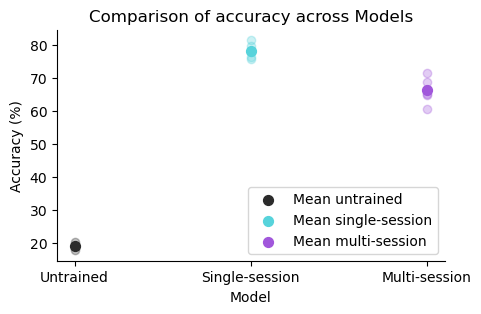

In [14]:
# PLOTTING

# Define pastel colors
colors = sns.color_palette("hls",8)
pastel_purple = colors[6]
pastel_blue = colors[4]
grey = sns.color_palette("Greys")[5]

# Extract the position error from each model
acc1 = results_untrained[:,2]
acc2 = results_single[:, 2]
acc3 = results_multi[:, 2]

# Compute the mean of the position error for each model
mean_error1 = np.mean(acc1)
mean_error2 = np.mean(acc2)
mean_error3 = np.mean(acc3)
fig, ax = plt.subplots(figsize=(5, 3))

# X positions for each model
x_positions = [1, 2, 3]

# Plot the position errors
ax.scatter(np.ones_like(acc1) * x_positions[0], acc1,color=grey, alpha = 0.3)
ax.scatter(np.ones_like(acc2) * x_positions[1], acc2, color=pastel_blue, alpha = 0.3)
ax.scatter(np.ones_like(acc3) * x_positions[2], acc3, color=pastel_purple, alpha = 0.3)
#edgecolors='black',
# Plot the means
ax.scatter(x_positions[0], mean_error1, color=grey,  s=50, label='Mean untrained', zorder=5)
ax.scatter(x_positions[1], mean_error2, color=pastel_blue, s=50, label='Mean single-session', zorder=5)
ax.scatter(x_positions[2], mean_error3, color=pastel_purple,  s=50, label='Mean multi-session', zorder=5)

# Set labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of accuracy across Models')
ax.set_xticks(x_positions)
ax.set_xticklabels(['Untrained', 'Single-session', 'Multi-session'])
ax.legend()
sns.despine()
# Show the plot
plt.show()

We have good decoding accuracy for the models, we can proceed to the analysis

# Neural Network Analysis

1. Put hooks on the model
2. Feed data and get activations (Y Matrix)
3. Create setup for GLM
  - X matrix (regressors normalized)
  - Y matrix (neural activation normalized by layer)


## Get activations for all models

**REMINDER** models variables are defined as follows:
- models_untrained  
- models_single  
- models_multi


### Define hooks and activation functions

In [15]:
# Function to create a hook that stores the activations in the dictionary
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().squeeze().numpy()
    return hook


def attach_hooks_conv(model,name,bool_train = False): # only attaches hooks on convolutional layers
  if not(bool_train): # attach _UT when it's not a trained model
    string_ut = 'UT'
  else:
    string_ut = ''
  num_conv = 1
  for i in range (len(model.net)):
    if isinstance(model.net[i], nn.Conv1d):
      model.net[i].register_forward_hook(get_activation(f'{name}{string_ut}_layer{num_conv}'))
      num_conv += 1

    elif bool(model.net[i]._modules): # empty dict evaluate to false. here we go in the _Skip connection where some conv may be stored
      for j in range (len(model.net[i].module)):
        if isinstance(model.net[i].module[j], nn.Conv1d):
          model.net[i].module[j].register_forward_hook(get_activation(f'{name}{string_ut}_layer{i}'))
          num_conv += 1


### Attach hooks and forward pass

In [16]:
data = data_train
label = label_train
label_extended = np.pad(label, ((5, 5)), mode="edge") #padding the labels to match the embedding sizes
# Dictionary to store activations of all models
activations = {}


# UNTRAINED
untrained_embeddings_train = []
attach_hooks_conv(models_untrained[1].model_[3],'multi',False)
attach_hooks_conv(models_untrained[0].model_,'single',False)

# do a forward pass
untrained_embeddings_train.append(models_untrained[1].transform(data,session_id = 3).T)
untrained_embeddings_train.append(models_untrained[0].transform(data).T)

# SINGLE
single_embeddings_train = []
for i,model in enumerate(models_single):
  attach_hooks_conv(model.model_,f'single{i}',True)
  single_embeddings_train.append(model.transform(data).T)

# MULTI
multi_embeddings_train = []
for i,model in enumerate(models_multi):
  attach_hooks_conv(model.model_[3],f'multi{i}',True)
  multi_embeddings_train.append(model.transform(data,session_id = 3).T)


print(activations.keys())


dict_keys(['multiUT_layer1', 'multiUT_layer2', 'multiUT_layer3', 'multiUT_layer4', 'multiUT_layer5', 'singleUT_layer1', 'singleUT_layer2', 'singleUT_layer3', 'singleUT_layer4', 'singleUT_layer5', 'single0_layer1', 'single0_layer2', 'single0_layer3', 'single0_layer4', 'single0_layer5', 'single1_layer1', 'single1_layer2', 'single1_layer3', 'single1_layer4', 'single1_layer5', 'single2_layer1', 'single2_layer2', 'single2_layer3', 'single2_layer4', 'single2_layer5', 'single3_layer1', 'single3_layer2', 'single3_layer3', 'single3_layer4', 'single3_layer5', 'single4_layer1', 'single4_layer2', 'single4_layer3', 'single4_layer4', 'single4_layer5', 'multi0_layer1', 'multi0_layer2', 'multi0_layer3', 'multi0_layer4', 'multi0_layer5', 'multi1_layer1', 'multi1_layer2', 'multi1_layer3', 'multi1_layer4', 'multi1_layer5', 'multi2_layer1', 'multi2_layer2', 'multi2_layer3', 'multi2_layer4', 'multi2_layer5', 'multi3_layer1', 'multi3_layer2', 'multi3_layer3', 'multi3_layer4', 'multi3_layer5', 'multi4_layer1

In [17]:
activations_UT_train = []
activations_single_train = []
activations_multi_train = []

# Populate matrices
for key, value in activations.items():
    parts = key.split('_')
    prefix = parts[0]

    if prefix == 'multiUT' or prefix == 'singleUT':
        activations_UT_train.append(value.squeeze())

    elif prefix.startswith('single'):
        activations_single_train.append(value.squeeze())

    elif prefix.startswith('multi'):
        activations_multi_train.append(value.squeeze())

In [18]:
activations_multi_train[0].shape

(32, 8108)

In [19]:
data = data_test
label = label_test
label_extended = np.pad(label, ((5, 5)), mode="edge") #padding the labels to match the embedding sizes
# Dictionary to store activations of all models
activations = {}


# UNTRAINED
untrained_embeddings_test = []
attach_hooks_conv(models_untrained[1].model_[3],'multi',False)
attach_hooks_conv(models_untrained[0].model_,'single',False)

# do a forward pass
untrained_embeddings_test.append(models_untrained[1].transform(data,session_id = 3).T)
untrained_embeddings_test.append(models_untrained[0].transform(data).T)

# SINGLE
single_embeddings_test = []
for i,model in enumerate(models_single):
  attach_hooks_conv(model.model_,f'single{i}',True)
  single_embeddings_test.append(model.transform(data).T)

# MULTI
multi_embeddings_test = []
for i,model in enumerate(models_multi):
  attach_hooks_conv(model.model_[3],f'multi{i}',True)
  multi_embeddings_test.append(model.transform(data,session_id = 3).T)


print(activations.keys())


dict_keys(['multiUT_layer1', 'multiUT_layer2', 'multiUT_layer3', 'multiUT_layer4', 'multiUT_layer5', 'singleUT_layer1', 'singleUT_layer2', 'singleUT_layer3', 'singleUT_layer4', 'singleUT_layer5', 'single0_layer1', 'single0_layer2', 'single0_layer3', 'single0_layer4', 'single0_layer5', 'single1_layer1', 'single1_layer2', 'single1_layer3', 'single1_layer4', 'single1_layer5', 'single2_layer1', 'single2_layer2', 'single2_layer3', 'single2_layer4', 'single2_layer5', 'single3_layer1', 'single3_layer2', 'single3_layer3', 'single3_layer4', 'single3_layer5', 'single4_layer1', 'single4_layer2', 'single4_layer3', 'single4_layer4', 'single4_layer5', 'multi0_layer1', 'multi0_layer2', 'multi0_layer3', 'multi0_layer4', 'multi0_layer5', 'multi1_layer1', 'multi1_layer2', 'multi1_layer3', 'multi1_layer4', 'multi1_layer5', 'multi2_layer1', 'multi2_layer2', 'multi2_layer3', 'multi2_layer4', 'multi2_layer5', 'multi3_layer1', 'multi3_layer2', 'multi3_layer3', 'multi3_layer4', 'multi3_layer5', 'multi4_layer1

In [20]:
activations_UT_test = []
activations_single_test = []
activations_multi_test = []

# Populate matrices
for key, value in activations.items():
    parts = key.split('_')
    prefix = parts[0]

    if prefix == 'multiUT' or prefix == 'singleUT':
        activations_UT_test.append(value.squeeze())

    elif prefix.startswith('single'):
        activations_single_test.append(value.squeeze())

    elif prefix.startswith('multi'):
        activations_multi_test.append(value.squeeze())

In [21]:
results_untrained = np.zeros((len(models_untrained),6,3))
results_single = np.zeros((len(models_single),6,3))
results_multi = np.zeros((len(models_multi),6,3))

label_extended_train = np.pad(discrete_labels_train[3], ((5, 5)), mode="edge") #padding the labels to match the embedding sizes
label_extended_test = np.pad(discrete_labels_val[3], ((5, 5)), mode="edge") 

labels_list_train = [label_extended_train[1:-1], label_extended_train[2:-2],label_extended_train[3:-3],label_extended_train[4:-4],
            label_extended_train[5:-5], label_extended_train[5:-5]]

labels_list_test = [label_extended_test[1:-1], label_extended_test[2:-2],label_extended_test[3:-3],label_extended_test[4:-4],
            label_extended_test[5:-5], label_extended_test[5:-5]]


embeddings_untrained_multi_train = activations_UT_train[:5] + [untrained_embeddings_train[0]]
embeddings_untrained_single_train = activations_UT_train[5:] + [untrained_embeddings_train[1]]

embeddings_untrained_multi_test = activations_UT_test[:5] + [untrained_embeddings_test[0]]
embeddings_untrained_single_test = activations_UT_test[5:] + [untrained_embeddings_test[1]]



# UNTRAINED
for i in range (2):
  print(i)
  for layer_nber in range(6):
    print('LAYER: ', layer_nber)
    if i == 1: # multi session, need to add the session id
      train = embeddings_untrained_multi_train[layer_nber].T
      test = embeddings_untrained_multi_test[layer_nber].T
    else:
      train = embeddings_untrained_single_train[layer_nber].T
      test = embeddings_untrained_single_test[layer_nber].T

    results_untrained[i,layer_nber,:] = decoding_frames(embedding_train=train,label_train=labels_list_train[layer_nber],embedding_test=test, label_test=labels_list_test[layer_nber])



# SINGLE
for i in range (5):
  embeddings_train = activations_single_train[i*5:5*(i+1)] + [single_embeddings_train[i]]
  embeddings_test = activations_single_test[i*5:5*(i+1)] + [single_embeddings_test[i]]

  for layer_nber in range(6):
    train = embeddings_train[layer_nber].T
    test = embeddings_test[layer_nber].T
    print(train.shape)
    print(test.shape)
    print(i)
    print(layer_nber)
    results_single[i,layer_nber,:] = decoding_frames(embedding_train=train,label_train=labels_list_train[layer_nber],embedding_test=test, label_test=labels_list_test[layer_nber])

# MULTI
for i in range(5):
  embeddings_train = activations_multi_train[i*5:5*(i+1)] + [multi_embeddings_train[i]]
  embeddings_test = activations_multi_test[i*5:5*(i+1)] + [multi_embeddings_test[i]]

  for layer_nber in range(6):
    train = embeddings_train[layer_nber].T
    test = embeddings_test[layer_nber].T
    results_multi[i,layer_nber,:] = decoding_frames(embedding_train=train,label_train=labels_list_train[layer_nber],embedding_test=test, label_test=labels_list_test[layer_nber])


0
LAYER:  0
LAYER:  1
LAYER:  2
LAYER:  3
LAYER:  4
LAYER:  5
1
LAYER:  0
LAYER:  1
LAYER:  2
LAYER:  3
LAYER:  4
LAYER:  5
(8108, 32)
(908, 32)
0
0
(8106, 32)
(906, 32)
0
1
(8104, 32)
(904, 32)
0
2
(8102, 32)
(902, 32)
0
3
(8100, 128)
(900, 128)
0
4
(8100, 128)
(900, 128)
0
5
(8108, 32)
(908, 32)
1
0
(8106, 32)
(906, 32)
1
1
(8104, 32)
(904, 32)
1
2
(8102, 32)
(902, 32)
1
3
(8100, 128)
(900, 128)
1
4
(8100, 128)
(900, 128)
1
5
(8108, 32)
(908, 32)
2
0
(8106, 32)
(906, 32)
2
1
(8104, 32)
(904, 32)
2
2
(8102, 32)
(902, 32)
2
3
(8100, 128)
(900, 128)
2
4
(8100, 128)
(900, 128)
2
5
(8108, 32)
(908, 32)
3
0
(8106, 32)
(906, 32)
3
1
(8104, 32)
(904, 32)
3
2
(8102, 32)
(902, 32)
3
3
(8100, 128)
(900, 128)
3
4
(8100, 128)
(900, 128)
3
5
(8108, 32)
(908, 32)
4
0
(8106, 32)
(906, 32)
4
1
(8104, 32)
(904, 32)
4
2
(8102, 32)
(902, 32)
4
3
(8100, 128)
(900, 128)
4
4
(8100, 128)
(900, 128)
4
5


In [22]:
# SINGLE
for i in range (5):
  embeddings_train = activations_single_train[i*5:5*(i+1)] + [single_embeddings_train[i]]
  embeddings_test = activations_single_test[i*5:5*(i+1)] + [single_embeddings_test[i]]

  for layer_nber in range(6):
    train = embeddings_train[layer_nber].T
    test = embeddings_test[layer_nber].T
    print(train.shape)
    print(test.shape)
    print(i)
    print(layer_nber)
    results_single[i,layer_nber,:] = decoding_frames(embedding_train=train,label_train=labels_list_train[layer_nber],embedding_test=test, label_test=labels_list_test[layer_nber])


(8108, 32)
(908, 32)
0
0
(8106, 32)
(906, 32)
0
1
(8104, 32)
(904, 32)
0
2
(8102, 32)
(902, 32)
0
3
(8100, 128)
(900, 128)
0
4
(8100, 128)
(900, 128)
0
5
(8108, 32)
(908, 32)
1
0
(8106, 32)
(906, 32)
1
1
(8104, 32)
(904, 32)
1
2
(8102, 32)
(902, 32)
1
3
(8100, 128)
(900, 128)
1
4
(8100, 128)
(900, 128)
1
5
(8108, 32)
(908, 32)
2
0
(8106, 32)
(906, 32)
2
1
(8104, 32)
(904, 32)
2
2
(8102, 32)
(902, 32)
2
3
(8100, 128)
(900, 128)
2
4
(8100, 128)
(900, 128)
2
5
(8108, 32)
(908, 32)
3
0
(8106, 32)
(906, 32)
3
1
(8104, 32)
(904, 32)
3
2
(8102, 32)
(902, 32)
3
3
(8100, 128)
(900, 128)
3
4
(8100, 128)
(900, 128)
3
5
(8108, 32)
(908, 32)
4
0
(8106, 32)
(906, 32)
4
1
(8104, 32)
(904, 32)
4
2
(8102, 32)
(902, 32)
4
3
(8100, 128)
(900, 128)
4
4
(8100, 128)
(900, 128)
4
5


In [23]:
results_baseline = decoding_frames(embedding_train=data_train,label_train=discrete_labels_train[3],embedding_test=data_test, label_test=discrete_labels_val[3])


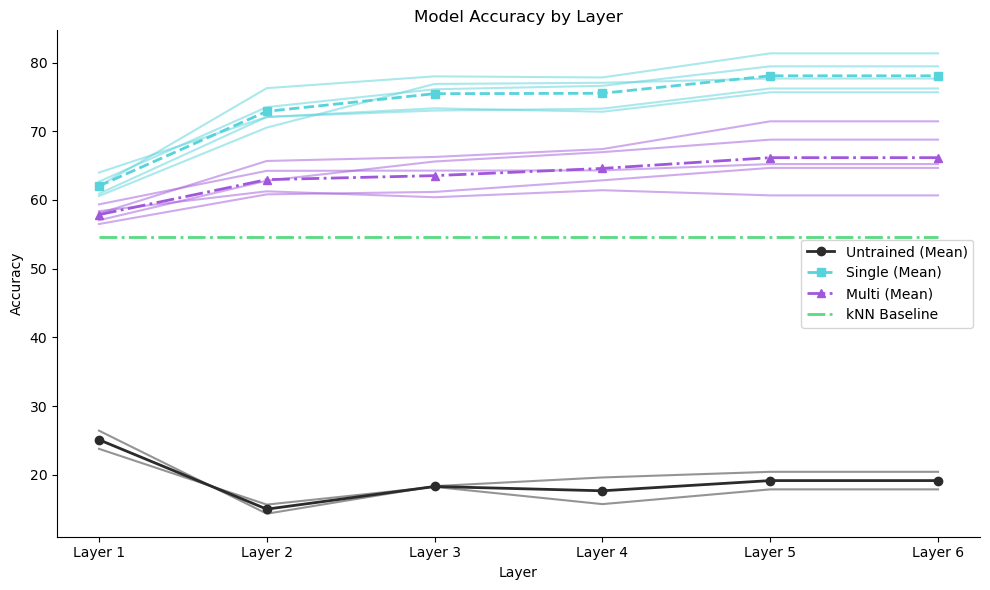

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the accuracy (assuming it's stored in the third column of the results arrays)
accuracy_untrained = results_untrained[:, :, 2]  # Shape: (models_untrained, layers, accuracy)
accuracy_single = results_single[:, :, 2]  # Shape: (models_single, layers, accuracy)
accuracy_multi = results_multi[:, :, 2]  # Shape: (models_multi, layers, accuracy)

# Create a plot for accuracy by layer
plt.figure(figsize=(10, 6))

# Plot individual instances for Untrained models
for i in range(accuracy_untrained.shape[0]):  # Loop through each untrained model instance
    plt.plot(accuracy_untrained[i], color=grey, alpha=0.5)  # Plot with transparency (alpha=0.5)
# Plot mean accuracy for Untrained models
plt.plot(np.mean(accuracy_untrained, axis=0), label='Untrained (Mean)', marker='o', linestyle='-', color=grey, linewidth=2)

# Plot individual instances for Single models
for i in range(accuracy_single.shape[0]):  # Loop through each single model instance
    plt.plot(accuracy_single[i], color=pastel_blue, alpha=0.5)  # Plot with transparency (alpha=0.5)
# Plot mean accuracy for Single models
plt.plot(np.mean(accuracy_single, axis=0), label='Single (Mean)', marker='s', linestyle='--', color=pastel_blue, linewidth=2)

# Plot individual instances for Multi models
for i in range(accuracy_multi.shape[0]):  # Loop through each multi model instance
    plt.plot(accuracy_multi[i], color=pastel_purple, alpha=0.5)  # Plot with transparency (alpha=0.5)
# Plot mean accuracy for Multi models
plt.plot(np.mean(accuracy_multi, axis=0), label='Multi (Mean)', marker='^', linestyle='-.', color=pastel_purple, linewidth=2)

#PLOT BASELINE
pastel_green = sns.color_palette("hls",8)[3]
plt.plot(results_baseline[2]*np.ones(6), label='kNN Baseline', linestyle='-.', color=pastel_green, linewidth=2)

# Customizing plot
plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.title('Model Accuracy by Layer')
plt.legend()
plt.xticks(np.arange(6), [f'Layer {i+1}' for i in range(6)])  # Label layers as Layer 1, Layer 2, ...
plt.grid(False)
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()
